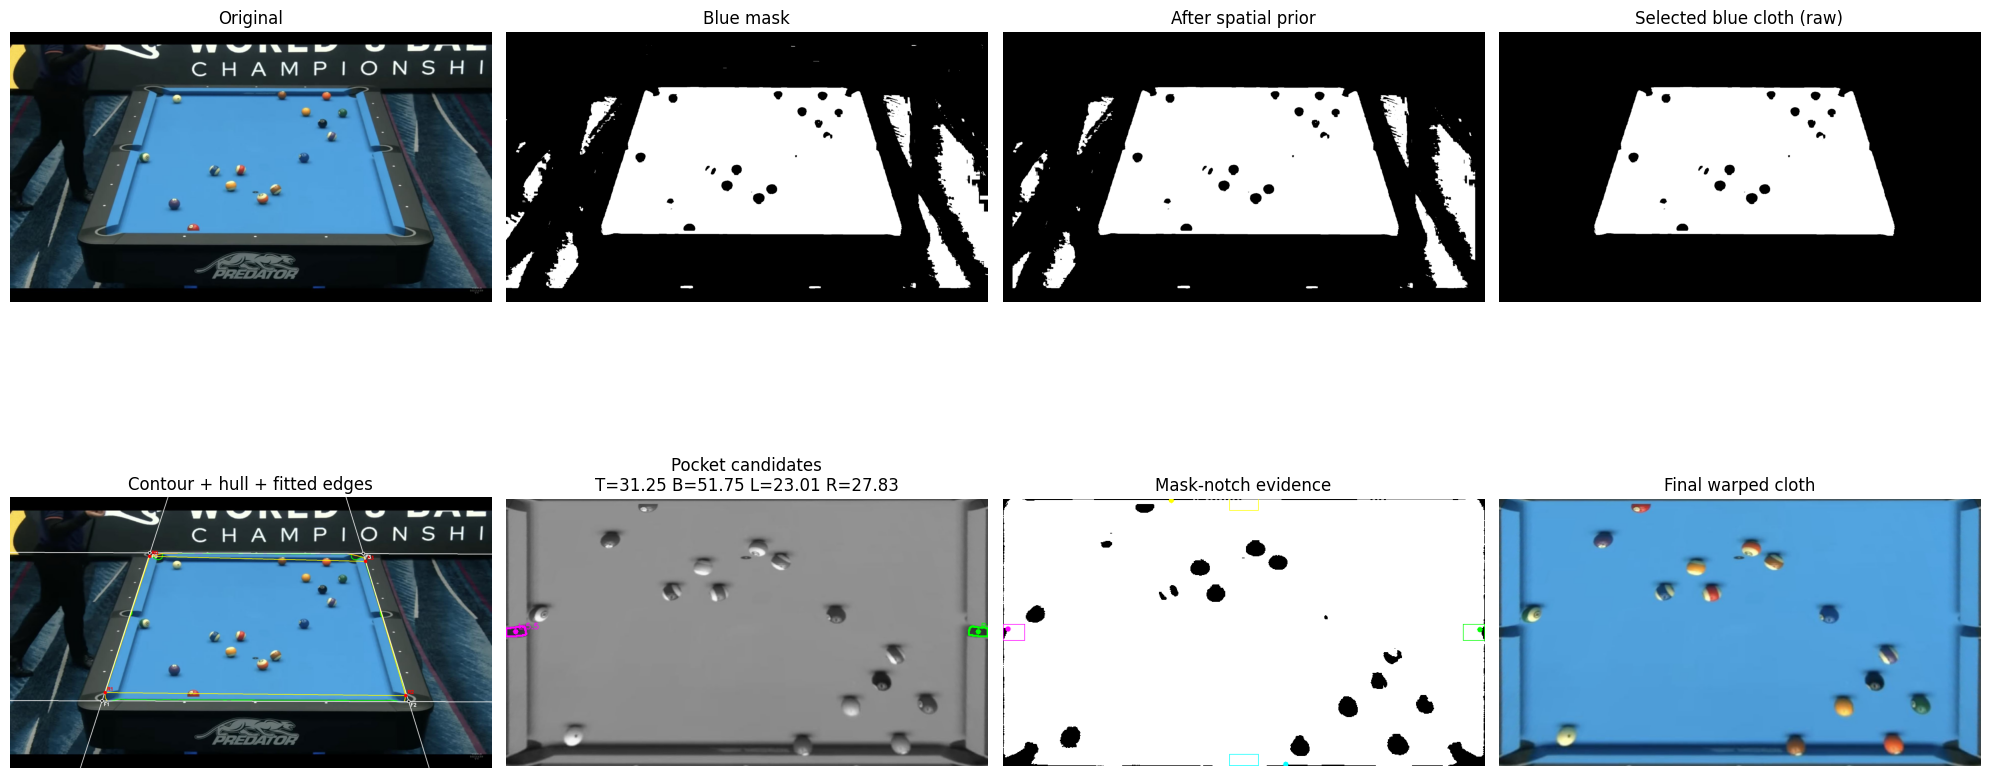


Rough corners:
[[ 556.  236.]
 [ 379.  779.]
 [1576.  791.]
 [1416.  256.]]

Refined cloth corners:
[[ 556.7779   222.16833]
 [ 366.25006  812.2567 ]
 [1588.177    814.8118 ]
 [1407.3911   225.41605]]

Oriented corners:
[[ 366.25006  812.2567 ]
 [1588.177    814.8118 ]
 [1407.3911   225.41605]
 [ 556.7779   222.16833]]

RGB strengths:
{'top': 0.0, 'bottom': 0.0, 'left': 5.513546942250581, 'right': 5.575459900845947}

Mask-notch strengths:
{'top': 125.0, 'bottom': 207.0, 'left': 70.0, 'right': 89.0}

Combined strengths:
{'top': 31.25, 'bottom': 51.75, 'left': 23.01354694225058, 'right': 27.825459900845946}

Horizontal score: 40.21426985536353
Vertical score: 25.305385348139424
Rotation k: 1
Notch weight: 0.25

Accepted RGB middle-pocket candidates:
{'side': 'left', 'area': np.int32(406), 'bbox': (0, 191, 31, 16), 'centroid': (14.450980392156861, 199.05608755129958), 'touch': 92, 'middle_offset': 0.9439124487004165, 'span': 16.0, 'depth': 14.450980392156861, 'score': 5.513546942250581}


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# ============================
# Geometry helpers
# ============================

def order_points_clockwise(pts):
    pts = np.asarray(pts, dtype=np.float32)
    center = np.mean(pts, axis=0)

    angles = np.arctan2(pts[:, 1] - center[1], pts[:, 0] - center[0])
    pts = pts[np.argsort(angles)]

    area2 = 0.0
    for i in range(len(pts)):
        x1, y1 = pts[i]
        x2, y2 = pts[(i + 1) % len(pts)]
        area2 += x1 * y2 - x2 * y1

    # enforce clockwise in image coordinates
    if area2 > 0:
        pts = pts[::-1]

    start_idx = np.argmin(pts[:, 0] + pts[:, 1])
    pts = np.roll(pts, -start_idx, axis=0)
    return pts.astype(np.float32)


def polygon_area(pts):
    pts = np.asarray(pts, dtype=np.float32)
    x = pts[:, 0]
    y = pts[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def line_from_two_points(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    a = y1 - y2
    b = x2 - x1
    c = x1 * y2 - x2 * y1
    return np.array([a, b, c], dtype=np.float32)


def intersect_lines(line1, line2):
    a1, b1, c1 = line1
    a2, b2, c2 = line2
    det = a1 * b2 - a2 * b1
    if abs(det) < 1e-8:
        return None
    x = (b1 * c2 - b2 * c1) / det
    y = (c1 * a2 - c2 * a1) / det
    return np.array([x, y], dtype=np.float32)


def clip_point_to_image(pt, w, h):
    x = float(np.clip(pt[0], 0, w - 1))
    y = float(np.clip(pt[1], 0, h - 1))
    return np.array([x, y], dtype=np.float32)


def normalize(v):
    v = np.asarray(v, dtype=np.float32)
    n = np.linalg.norm(v) + 1e-8
    return v / n


def point_to_line_distance(line, points):
    a, b, c = line
    points = np.asarray(points, dtype=np.float32)
    denom = np.sqrt(a * a + b * b) + 1e-8
    return np.abs(a * points[:, 0] + b * points[:, 1] + c) / denom


def point_to_segment_distance(points, a, b):
    points = np.asarray(points, dtype=np.float32)
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)

    ab = b - a
    ab2 = np.dot(ab, ab) + 1e-8
    ap = points - a[None, :]
    t = np.sum(ap * ab[None, :], axis=1) / ab2
    t = np.clip(t, 0.0, 1.0)
    proj = a[None, :] + t[:, None] * ab[None, :]
    return np.linalg.norm(points - proj, axis=1)


def line_to_border_points(line, w, h):
    a, b, c = line
    pts = []

    if abs(b) > 1e-8:
        y = -(a * 0 + c) / b
        if 0 <= y < h:
            pts.append(np.array([0, y], dtype=np.float32))
        y = -(a * (w - 1) + c) / b
        if 0 <= y < h:
            pts.append(np.array([w - 1, y], dtype=np.float32))

    if abs(a) > 1e-8:
        x = -(b * 0 + c) / a
        if 0 <= x < w:
            pts.append(np.array([x, 0], dtype=np.float32))
        x = -(b * (h - 1) + c) / a
        if 0 <= x < w:
            pts.append(np.array([x, h - 1], dtype=np.float32))

    if len(pts) < 2:
        return None

    best_pair = None
    best_d = -1
    for i in range(len(pts)):
        for j in range(i + 1, len(pts)):
            d = np.linalg.norm(pts[i] - pts[j])
            if d > best_d:
                best_d = d
                best_pair = (pts[i], pts[j])
    return best_pair


# ============================
# Robust line fitting
# ============================

def fit_line_to_points_huber(points):
    points = np.asarray(points, dtype=np.float32).reshape(-1, 1, 2)
    vx, vy, x0, y0 = cv2.fitLine(points, cv2.DIST_HUBER, 0, 0.01, 0.01).flatten()

    p1 = np.array([x0 - 3000 * vx, y0 - 3000 * vy], dtype=np.float32)
    p2 = np.array([x0 + 3000 * vx, y0 + 3000 * vy], dtype=np.float32)
    return line_from_two_points(p1, p2)


def robust_fit_line_iterative(points, max_iters=8, min_points=20):
    pts = np.asarray(points, dtype=np.float32)
    if len(pts) < min_points:
        raise ValueError(f"Not enough points for robust line fitting: {len(pts)}")

    current = pts.copy()

    for _ in range(max_iters):
        if len(current) < min_points:
            break

        line = fit_line_to_points_huber(current)
        d = point_to_line_distance(line, current)

        med = np.median(d)
        mad = np.median(np.abs(d - med)) + 1e-6
        thresh = max(1.5, med + 2.5 * 1.4826 * mad)

        inliers = d <= thresh
        if np.all(inliers):
            break
        if np.count_nonzero(inliers) < min_points:
            break

        current = current[inliers]

    line = fit_line_to_points_huber(current)
    return line, current


# ============================
# Segmentation
# ============================

def segment_table_blue(image_bgr):
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)

    lower_blue = np.array([85, 70, 70], dtype=np.uint8)
    upper_blue = np.array([125, 255, 255], dtype=np.uint8)

    mask_hsv = cv2.inRange(hsv, lower_blue, upper_blue)

    b, g, r = cv2.split(image_bgr)
    blue_dom = (
        (b.astype(np.int16) > g.astype(np.int16) + 10) &
        (b.astype(np.int16) > r.astype(np.int16) + 10)
    ).astype(np.uint8) * 255

    return cv2.bitwise_and(mask_hsv, blue_dom)


def apply_spatial_prior(mask):
    h, w = mask.shape
    roi_mask = np.zeros_like(mask)
    y0 = int(0.17 * h)
    x0 = int(0.02 * w)
    x1 = int(0.98 * w)
    roi_mask[y0:h, x0:x1] = 255
    return cv2.bitwise_and(mask, roi_mask)


def component_score(stats_row, image_area):
    area = stats_row[cv2.CC_STAT_AREA]
    bw = stats_row[cv2.CC_STAT_WIDTH]
    bh = stats_row[cv2.CC_STAT_HEIGHT]

    if bw <= 0 or bh <= 0:
        return -1e9

    bbox_area = bw * bh
    extent = area / (bbox_area + 1e-8)
    aspect = bw / (bh + 1e-8)

    if area < 0.01 * image_area:
        return -1e9
    if not (0.8 <= aspect <= 5.5):
        return -1e9
    if not (0.25 <= extent <= 0.98):
        return -1e9

    return 2.0 * area + 50000.0 * extent


def suppress_top_text_components(mask, top_frac=0.28, max_area_frac=0.003, min_width_frac=0.25):
    h, w = mask.shape
    image_area = h * w

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
    cleaned = np.zeros_like(mask)

    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]
        bw = stats[label, cv2.CC_STAT_WIDTH]
        _, cy = centroids[label]

        keep = True
        if cy < top_frac * h:
            if area < max_area_frac * image_area and bw < min_width_frac * w:
                keep = False

        if keep:
            cleaned[labels == label] = 255

    return cleaned


def find_best_table_component(mask):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    if num_labels <= 1:
        raise ValueError("No connected components found.")

    h, w = mask.shape
    image_area = h * w

    best_label = None
    best_score = -1e18

    for label in range(1, num_labels):
        score = component_score(stats[label], image_area)
        if score > best_score:
            best_score = score
            best_label = label

    if best_label is None:
        raise ValueError("No valid blue-cloth component found.")

    component_mask = np.zeros_like(mask)
    component_mask[labels == best_label] = 255
    return component_mask


def fill_table_component(mask_table):
    contours, _ = cv2.findContours(mask_table, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        raise ValueError("No contour found in selected table component.")

    contour = max(contours, key=cv2.contourArea)

    filled = np.zeros_like(mask_table)
    cv2.drawContours(filled, [contour], -1, 255, -1)

    filled = cv2.morphologyEx(
        filled, cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (31, 31))
    )

    return filled


def get_largest_contour(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        raise ValueError("No contour found.")
    return max(contours, key=cv2.contourArea)


def build_hull_mask(mask):
    contour = get_largest_contour(mask)
    hull = cv2.convexHull(contour, returnPoints=True)

    hull_mask = np.zeros_like(mask)
    cv2.drawContours(hull_mask, [hull], -1, 255, -1)
    return contour, hull, hull_mask


# ============================
# Rough quadrilateral from hull contour
# ============================

def detect_initial_corners_from_contour(contour):
    perimeter = cv2.arcLength(contour, True)
    contour_area = cv2.contourArea(contour)

    best_pts = None
    best_score = -np.inf

    for factor in np.linspace(0.002, 0.08, 100):
        epsilon = factor * perimeter
        approx = cv2.approxPolyDP(contour, epsilon, True)

        if len(approx) != 4:
            continue

        pts = approx.reshape(4, 2).astype(np.float32)
        pts = order_points_clockwise(pts)

        if not cv2.isContourConvex(np.round(pts).astype(np.int32)):
            continue

        quad_area = polygon_area(pts)
        if quad_area < 0.70 * contour_area:
            continue

        edges = np.array([
            np.linalg.norm(pts[1] - pts[0]),
            np.linalg.norm(pts[2] - pts[1]),
            np.linalg.norm(pts[3] - pts[2]),
            np.linalg.norm(pts[0] - pts[3]),
        ], dtype=np.float32)

        opp_similarity = (
            min(edges[0], edges[2]) / (max(edges[0], edges[2]) + 1e-6) +
            min(edges[1], edges[3]) / (max(edges[1], edges[3]) + 1e-6)
        )

        bbox_w = float(np.max(pts[:, 0]) - np.min(pts[:, 0]))
        bbox_h = float(np.max(pts[:, 1]) - np.min(pts[:, 1]))
        if bbox_w < 1 or bbox_h < 1:
            continue

        bbox_fill = quad_area / (bbox_w * bbox_h + 1e-6)
        score = (
            2.0 * (quad_area / (contour_area + 1e-6)) +
            1.5 * opp_similarity +
            0.8 * bbox_fill
        )

        if score > best_score:
            best_score = score
            best_pts = pts

    if best_pts is not None:
        return best_pts

    rect = cv2.minAreaRect(contour)
    pts = cv2.boxPoints(rect).astype(np.float32)
    return order_points_clockwise(pts)


# ============================
# Side assignment + dense hull-contour fitting
# ============================

def split_points_by_quad_sides(points, quad):
    quad = order_points_clockwise(quad)
    pts = np.asarray(points, dtype=np.float32)

    sides = [
        (quad[0], quad[1]),
        (quad[1], quad[2]),
        (quad[2], quad[3]),
        (quad[3], quad[0]),
    ]

    dist_stack = []
    for a, b in sides:
        dist_stack.append(point_to_segment_distance(pts, a, b))

    dist_stack = np.stack(dist_stack, axis=1)
    labels = np.argmin(dist_stack, axis=1)
    side_points = [pts[labels == i] for i in range(4)]
    return side_points, labels


def trim_points_along_side(points, a, b, keep_ratio=0.70):
    pts = np.asarray(points, dtype=np.float32)
    if len(pts) < 20:
        return pts

    d = normalize(b - a)
    t = pts @ d
    order = np.argsort(t)
    pts_sorted = pts[order]

    n = len(pts_sorted)
    margin = int(round((1.0 - keep_ratio) * 0.5 * n))
    if 2 * margin >= n:
        return pts_sorted
    return pts_sorted[margin:n - margin]


def fit_side_lines_from_dense_hull_contour(hull_contour, rough_quad):
    pts = hull_contour.reshape(-1, 2).astype(np.float32)
    rough_quad = order_points_clockwise(rough_quad)

    side_points, _ = split_points_by_quad_sides(pts, rough_quad)

    sides = [
        (rough_quad[0], rough_quad[1]),
        (rough_quad[1], rough_quad[2]),
        (rough_quad[2], rough_quad[3]),
        (rough_quad[3], rough_quad[0]),
    ]

    fitted_lines = []
    trimmed_sets = []
    inlier_sets = []

    for i, side_pts in enumerate(side_points):
        if len(side_pts) < 20:
            raise ValueError(f"Too few dense hull-contour points for side {i}: {len(side_pts)}")

        a, b = sides[i]
        pts_trimmed = trim_points_along_side(side_pts, a, b, keep_ratio=0.70)
        if len(pts_trimmed) < 20:
            pts_trimmed = side_pts

        line, inliers = robust_fit_line_iterative(
            pts_trimmed,
            max_iters=8,
            min_points=20
        )

        fitted_lines.append(line)
        trimmed_sets.append(pts_trimmed)
        inlier_sets.append(inliers)

    debug = {
        "side_points": side_points,
        "trimmed_sets": trimmed_sets,
        "inlier_sets": inlier_sets,
        "fitted_lines": fitted_lines,
    }
    return fitted_lines, debug


def refine_corners_from_lines(fitted_lines, image_shape):
    h, w = image_shape[:2]

    top, right, bottom, left = fitted_lines

    tl = intersect_lines(left, top)
    tr = intersect_lines(top, right)
    br = intersect_lines(right, bottom)
    bl = intersect_lines(bottom, left)

    refined = [tl, tr, br, bl]
    if any(p is None for p in refined):
        raise ValueError("Failed to intersect fitted side lines.")

    refined = np.array([clip_point_to_image(p, w, h) for p in refined], dtype=np.float32)
    refined = order_points_clockwise(refined)
    return refined


def quad_is_reasonable(quad, image_shape):
    quad = order_points_clockwise(quad)
    h, w = image_shape[:2]
    img_area = h * w
    area = polygon_area(quad)

    if area < 0.02 * img_area:
        return False

    edges = np.array([
        np.linalg.norm(quad[1] - quad[0]),
        np.linalg.norm(quad[2] - quad[1]),
        np.linalg.norm(quad[3] - quad[2]),
        np.linalg.norm(quad[0] - quad[3]),
    ], dtype=np.float32)

    return np.min(edges) >= 20


# ============================
# Warp
# ============================

def warp_from_corners(image_bgr, corners, out_w=720, out_h=400, assume_ordered=False):
    if not assume_ordered:
        corners = order_points_clockwise(corners)
    else:
        corners = np.asarray(corners, dtype=np.float32)

    dst = np.array([
        [0, 0],
        [out_w - 1, 0],
        [out_w - 1, out_h - 1],
        [0, out_h - 1]
    ], dtype=np.float32)

    H = cv2.getPerspectiveTransform(corners.astype(np.float32), dst)
    warped = cv2.warpPerspective(image_bgr, H, (out_w, out_h))
    return warped, H


def warp_mask_from_corners(mask, corners, out_w=720, out_h=400, assume_ordered=False):
    if not assume_ordered:
        corners = order_points_clockwise(corners)
    else:
        corners = np.asarray(corners, dtype=np.float32)

    dst = np.array([
        [0, 0],
        [out_w - 1, 0],
        [out_w - 1, out_h - 1],
        [0, out_h - 1]
    ], dtype=np.float32)

    H = cv2.getPerspectiveTransform(corners.astype(np.float32), dst)
    warped = cv2.warpPerspective(mask, H, (out_w, out_h), flags=cv2.INTER_NEAREST)
    return warped, H


def warp_from_corners_auto(image_bgr, corners, assume_ordered=False):
    if not assume_ordered:
        corners = order_points_clockwise(corners)
    else:
        corners = np.asarray(corners, dtype=np.float32)

    w_top = np.linalg.norm(corners[1] - corners[0])
    w_bottom = np.linalg.norm(corners[2] - corners[3])
    h_left = np.linalg.norm(corners[3] - corners[0])
    h_right = np.linalg.norm(corners[2] - corners[1])

    out_w = int(round(max(w_top, w_bottom)))
    out_h = int(round(max(h_left, h_right)))
    out_w = max(out_w, 200)
    out_h = max(out_h, 120)

    return warp_from_corners(
        image_bgr,
        corners,
        out_w=out_w,
        out_h=out_h,
        assume_ordered=True
    )


# ============================
# Middle-pocket detection
# ============================

def build_inner_side_strips(warped_table_mask, strip_frac=0.03):
    """
    Thin strips just inside the cloth boundary.
    Pocket evidence should touch these strips.
    """
    table = (warped_table_mask > 0).astype(np.uint8) * 255
    h, w = table.shape

    d = max(4, int(round(strip_frac * min(h, w))))

    top = np.zeros_like(table)
    bottom = np.zeros_like(table)
    left = np.zeros_like(table)
    right = np.zeros_like(table)

    top[:d, :] = 255
    bottom[h - d:, :] = 255
    left[:, :d] = 255
    right[:, w - d:] = 255

    return {
        "top": cv2.bitwise_and(table, top),
        "bottom": cv2.bitwise_and(table, bottom),
        "left": cv2.bitwise_and(table, left),
        "right": cv2.bitwise_and(table, right),
    }


def detect_middle_pocket_scores_in_warp(warped_bgr, warped_table_mask, dark_thresh=70):
    
    gray = cv2.cvtColor(warped_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    dark = (blur < dark_thresh).astype(np.uint8) * 255
    dark = cv2.morphologyEx(
        dark, cv2.MORPH_OPEN,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    )
    dark = cv2.morphologyEx(
        dark, cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    )

    strips = build_inner_side_strips(warped_table_mask, strip_frac=0.03)

    zones = {
        "top": (
            slice(0, int(0.045 * h)),
            slice(int(0.47 * w), int(0.53 * w))
        ),
        "bottom": (
            slice(int(0.955 * h), h),
            slice(int(0.47 * w), int(0.53 * w))
        ),
        "left": (
            slice(int(0.47 * h), int(0.53 * h)),
            slice(0, int(0.045 * w))
        ),
        "right": (
            slice(int(0.47 * h), int(0.53 * h)),
            slice(int(0.955 * w), w)
        ),
    }
    
    strengths = {"top": 0.0, "bottom": 0.0, "left": 0.0, "right": 0.0}
    accepted = []
    rejected = []

    candidate_vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    zone_vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    strip_vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    side_colors = {
        "top": (0, 255, 255),
        "bottom": (255, 255, 0),
        "left": (255, 0, 255),
        "right": (0, 255, 0),
    }

    for side, strip_mask in strips.items():
        color = side_colors[side]
        strip_vis[strip_mask > 0] = (
            0.6 * strip_vis[strip_mask > 0] + 0.4 * np.array(color)
        ).astype(np.uint8)

    img_area = h * w
    min_area = max(30, int(0.00008 * img_area))
    max_area = max(120, int(0.010 * img_area))

    for side, (ys, xs) in zones.items():
        cv2.rectangle(zone_vis, (xs.start, ys.start), (xs.stop - 1, ys.stop - 1), (255, 255, 255), 1)

        zone_mask = np.zeros_like(dark)
        zone_mask[ys, xs] = 255

        candidate_mask = cv2.bitwise_and(dark, zone_mask)

        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(candidate_mask, connectivity=8)

        for lab in range(1, num_labels):
            area = stats[lab, cv2.CC_STAT_AREA]

            comp = np.zeros_like(dark)
            comp[labels == lab] = 255

            contours, _ = cv2.findContours(comp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if not contours:
                continue
            cnt = max(contours, key=cv2.contourArea)

            x, y, bw, bh = cv2.boundingRect(cnt)

            M = cv2.moments(cnt)
            if M["m00"] <= 1e-6:
                continue
            cx = M["m10"] / M["m00"]
            cy = M["m01"] / M["m00"]

            reason = None

            if area < min_area or area > max_area:
                reason = "area"
            else:
                touch = np.count_nonzero((comp > 0) & (strips[side] > 0))
                min_touch = 10
                if touch < min_touch:
                    reason = "low_strip_touch"
                else:
                    if side in ("top", "bottom"):
                        middle_offset = abs(cx - 0.5 * w)
                        max_middle_offset = 0.05 * w
                        span = bw
                        min_span = 0.035 * w
                        depth = cy if side == "top" else (h - 1 - cy)
                        max_depth = 0.022 * h
                    else:
                        middle_offset = abs(cy - 0.5 * h)
                        max_middle_offset = 0.05 * h
                        span = bh
                        min_span = 0.035 * h
                        depth = cx if side == "left" else (w - 1 - cx)
                        max_depth = 0.022 * w

                    if middle_offset > max_middle_offset:
                        reason = "off_center"
                    elif span < min_span:
                        reason = "too_small_span"
                    elif depth > max_depth:
                        reason = "too_deep"
                    else:
                        center_score = max(0.0, 1.0 - middle_offset / (max_middle_offset + 1e-6))
                        span_score = min(1.0, span / (0.06 * (w if side in ("top", "bottom") else h) + 1e-6))
                        depth_score = max(0.0, 1.0 - depth / (max_depth + 1e-6))
                        touch_score = min(1.0, touch / 25.0)

                        score = (
                            2.5 * center_score +
                            1.5 * span_score +
                            1.5 * depth_score +
                            2.0 * touch_score
                        )

                        strengths[side] += float(score)
                        accepted.append({
                            "side": side,
                            "area": area,
                            "bbox": (x, y, bw, bh),
                            "centroid": (cx, cy),
                            "touch": int(touch),
                            "middle_offset": float(middle_offset),
                            "span": float(span),
                            "depth": float(depth),
                            "score": float(score),
                        })

                        color = side_colors[side]
                        cv2.drawContours(candidate_vis, [cnt], -1, color, 2)
                        cv2.circle(candidate_vis, (int(round(cx)), int(round(cy))), 4, color, -1)
                        cv2.putText(
                            candidate_vis,
                            f"{side[0].upper()}:{score:.1f}",
                            (int(round(cx)) + 4, int(round(cy)) - 4),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.4,
                            color,
                            1,
                            cv2.LINE_AA
                        )

            if reason is not None:
                rejected.append({
                    "side": side,
                    "bbox": (x, y, bw, bh),
                    "centroid": (cx, cy),
                    "reason": reason,
                })
                cv2.drawContours(candidate_vis, [cnt], -1, (255, 0, 0), 1)

    debug = {
        "gray": gray,
        "dark_mask": dark,
        "zone_vis": zone_vis,
        "strip_vis": strip_vis,
        "candidate_vis": candidate_vis,
        "accepted": accepted,
        "rejected": rejected,
        "strengths": strengths,
        "strips": strips,
    }
    return strengths, debug


def detect_middle_pocket_strengths_from_mask_notches(warped_table_mask):
    """
    Uses the RAW warped mask.
    Middle pockets appear as inward notches in the cloth silhouette.
    """
    table = (warped_table_mask > 0).astype(np.uint8)
    h, w = table.shape

    strengths = {"top": 0.0, "bottom": 0.0, "left": 0.0, "right": 0.0}

    x0, x1 = int(0.35 * w), int(0.65 * w)
    y0, y1 = int(0.35 * h), int(0.65 * h)

    top_profile = []
    for x in range(x0, x1):
        ys = np.where(table[:, x] > 0)[0]
        top_profile.append(h if len(ys) == 0 else int(ys[0]))
    top_profile = np.array(top_profile, dtype=np.float32)
    top_baseline = np.percentile(top_profile, 15)
    top_notch = np.maximum(0.0, top_profile - top_baseline)
    strengths["top"] = float(np.sum(top_notch))

    bottom_profile = []
    for x in range(x0, x1):
        ys = np.where(table[:, x] > 0)[0]
        bottom_profile.append(-1 if len(ys) == 0 else int(ys[-1]))
    bottom_profile = np.array(bottom_profile, dtype=np.float32)
    bottom_baseline = np.percentile(bottom_profile, 85)
    bottom_notch = np.maximum(0.0, bottom_baseline - bottom_profile)
    strengths["bottom"] = float(np.sum(bottom_notch))

    left_profile = []
    for y in range(y0, y1):
        xs = np.where(table[y, :] > 0)[0]
        left_profile.append(w if len(xs) == 0 else int(xs[0]))
    left_profile = np.array(left_profile, dtype=np.float32)
    left_baseline = np.percentile(left_profile, 15)
    left_notch = np.maximum(0.0, left_profile - left_baseline)
    strengths["left"] = float(np.sum(left_notch))

    right_profile = []
    for y in range(y0, y1):
        xs = np.where(table[y, :] > 0)[0]
        right_profile.append(-1 if len(xs) == 0 else int(xs[-1]))
    right_profile = np.array(right_profile, dtype=np.float32)
    right_baseline = np.percentile(right_profile, 85)
    right_notch = np.maximum(0.0, right_baseline - right_profile)
    strengths["right"] = float(np.sum(right_notch))

    debug = {
        "top_profile": top_profile,
        "bottom_profile": bottom_profile,
        "left_profile": left_profile,
        "right_profile": right_profile,
        "top_notch": top_notch,
        "bottom_notch": bottom_notch,
        "left_notch": left_notch,
        "right_notch": right_notch,
    }
    return strengths, debug


def visualize_mask_notches(warped_table_mask, notch_debug):
    table = (warped_table_mask > 0).astype(np.uint8) * 255
    vis = cv2.cvtColor(table, cv2.COLOR_GRAY2BGR)
    h, w = table.shape

    cv2.rectangle(vis, (int(0.47 * w), 0), (int(0.53 * w), int(0.045 * h)), (0, 255, 255), 1)
    cv2.rectangle(vis, (int(0.47 * w), int(0.955 * h)), (int(0.53 * w), h - 1), (255, 255, 0), 1)
    cv2.rectangle(vis, (0, int(0.47 * h)), (int(0.045 * w), int(0.53 * h)), (255, 0, 255), 1)
    cv2.rectangle(vis, (int(0.955 * w), int(0.47 * h)), (w - 1, int(0.53 * h)), (0, 255, 0), 1)

    if len(notch_debug["top_notch"]) > 0:
        top_idx = int(np.argmax(notch_debug["top_notch"]))
        x_top = int(0.35 * w) + top_idx
        cv2.circle(vis, (x_top, int(notch_debug["top_profile"][top_idx])), 4, (0, 255, 255), -1)

    if len(notch_debug["bottom_notch"]) > 0:
        bottom_idx = int(np.argmax(notch_debug["bottom_notch"]))
        x_bottom = int(0.35 * w) + bottom_idx
        cv2.circle(vis, (x_bottom, int(notch_debug["bottom_profile"][bottom_idx])), 4, (255, 255, 0), -1)

    if len(notch_debug["left_notch"]) > 0:
        left_idx = int(np.argmax(notch_debug["left_notch"]))
        y_left = int(0.35 * h) + left_idx
        cv2.circle(vis, (int(notch_debug["left_profile"][left_idx]), y_left), 4, (255, 0, 255), -1)

    if len(notch_debug["right_notch"]) > 0:
        right_idx = int(np.argmax(notch_debug["right_notch"]))
        y_right = int(0.35 * h) + right_idx
        cv2.circle(vis, (int(notch_debug["right_profile"][right_idx]), y_right), 4, (0, 255, 0), -1)

    return vis

def decide_corner_rotation_using_middle_pockets(
    image_bgr,
    raw_mask_table,
    corners,
    tmp_w=720,
    tmp_h=400,
    notch_weight=0.25,
    geom_weight=2.0
):
    canonical = order_points_clockwise(corners)

    def side_lengths(c):
        w_top = np.linalg.norm(c[1] - c[0])
        w_bottom = np.linalg.norm(c[2] - c[3])
        h_left = np.linalg.norm(c[3] - c[0])
        h_right = np.linalg.norm(c[2] - c[1])
        width_est = 0.5 * (w_top + w_bottom)
        height_est = 0.5 * (h_left + h_right)
        return width_est, height_est

    def evaluate(c):
        warped_img, _ = warp_from_corners(
            image_bgr, c, out_w=tmp_w, out_h=tmp_h, assume_ordered=True
        )
        warped_mask, _ = warp_mask_from_corners(
            raw_mask_table, c, out_w=tmp_w, out_h=tmp_h, assume_ordered=True
        )

        rgb_strengths, rgb_debug = detect_middle_pocket_scores_in_warp(
            warped_img, warped_mask, dark_thresh=70
        )
        notch_strengths, notch_debug = detect_middle_pocket_strengths_from_mask_notches(
            warped_mask
        )
        notch_vis = visualize_mask_notches(warped_mask, notch_debug)

        strengths = {
            "top": rgb_strengths["top"] + notch_weight * notch_strengths["top"],
            "bottom": rgb_strengths["bottom"] + notch_weight * notch_strengths["bottom"],
            "left": rgb_strengths["left"] + notch_weight * notch_strengths["left"],
            "right": rgb_strengths["right"] + notch_weight * notch_strengths["right"],
        }
        #testin
        horizontal_score = np.sqrt(max(strengths["top"], 0.0) * max(strengths["bottom"], 0.0))
        vertical_score = np.sqrt(max(strengths["left"], 0.0) * max(strengths["right"], 0.0))

        width_est, height_est = side_lengths(c)

        # positive if this orientation maps long side horizontally
        geom_score = (width_est - height_est) / (max(width_est, height_est) + 1e-6)

        # final score: prefer horizontal middle pockets and landscape geometry
        total_score = (horizontal_score - vertical_score) + geom_weight * geom_score

        return {
            "corners": c,
            "warped_tmp": warped_img,
            "warped_tmp_mask": warped_mask,
            "dark_mask": rgb_debug["dark_mask"],
            "zone_vis": rgb_debug["zone_vis"],
            "strip_vis": rgb_debug["strip_vis"],
            "candidate_vis": rgb_debug["candidate_vis"],
            "accepted": rgb_debug["accepted"],
            "rejected": rgb_debug["rejected"],
            "rgb_strengths": rgb_strengths,
            "notch_strengths": notch_strengths,
            "strengths": strengths,
            "horizontal_score": horizontal_score,
            "vertical_score": vertical_score,
            "geom_score": geom_score,
            "total_score": total_score,
            "notch_vis": notch_vis,
            "width_est": width_est,
            "height_est": height_est,
        }

    # only need to compare the 2 aspect-swapped orientations
    cand0 = evaluate(np.roll(canonical, 0, axis=0).astype(np.float32))
    cand1 = evaluate(np.roll(canonical, -1, axis=0).astype(np.float32))

    chosen = cand1 if cand1["total_score"] > cand0["total_score"] else cand0

    debug = {
        "candidate0_horizontal_score": cand0["horizontal_score"],
        "candidate0_vertical_score": cand0["vertical_score"],
        "candidate0_geom_score": cand0["geom_score"],
        "candidate0_total_score": cand0["total_score"],
        "candidate0_strengths": cand0["strengths"],
        "candidate0_width_est": cand0["width_est"],
        "candidate0_height_est": cand0["height_est"],

        "candidate1_horizontal_score": cand1["horizontal_score"],
        "candidate1_vertical_score": cand1["vertical_score"],
        "candidate1_geom_score": cand1["geom_score"],
        "candidate1_total_score": cand1["total_score"],
        "candidate1_strengths": cand1["strengths"],
        "candidate1_width_est": cand1["width_est"],
        "candidate1_height_est": cand1["height_est"],

        "rotation_k": 1 if chosen is cand1 else 0,
        "rotated_90": chosen is cand1,

        "warped_tmp": chosen["warped_tmp"],
        "warped_tmp_mask": chosen["warped_tmp_mask"],
        "dark_mask": chosen["dark_mask"],
        "zone_vis": chosen["zone_vis"],
        "strip_vis": chosen["strip_vis"],
        "candidate_vis": chosen["candidate_vis"],
        "accepted": chosen["accepted"],
        "rejected": chosen["rejected"],
        "rgb_strengths": chosen["rgb_strengths"],
        "notch_strengths": chosen["notch_strengths"],
        "strengths": chosen["strengths"],
        "horizontal_score": chosen["horizontal_score"],
        "vertical_score": chosen["vertical_score"],
        "geom_score": chosen["geom_score"],
        "total_score": chosen["total_score"],
        "notch_vis": chosen["notch_vis"],
        "notch_weight": notch_weight,
        "geom_weight": geom_weight,
    }

    return chosen["corners"], debug


# ============================
# Visualization
# ============================

def draw_debug_overlay(image_bgr, contour, hull, hull_contour, rough_corners, refined_corners, debug):
    vis = image_bgr.copy()
    h, w = vis.shape[:2]

    cv2.drawContours(vis, [contour], -1, (0, 255, 0), 2)
    cv2.drawContours(vis, [hull], -1, (255, 0, 0), 2)
    cv2.drawContours(vis, [hull_contour], -1, (0, 200, 255), 2)

    rc = np.round(rough_corners).astype(np.int32).reshape(-1, 1, 2)
    cv2.drawContours(vis, [rc], -1, (0, 255, 255), 2)

    side_colors = [
        (255, 255, 0),
        (255, 0, 255),
        (0, 165, 255),
        (180, 255, 180),
    ]

    for i, pts in enumerate(debug["trimmed_sets"]):
        color = side_colors[i % len(side_colors)]
        for p in pts:
            x, y = int(p[0]), int(p[1])
            cv2.circle(vis, (x, y), 1, color, -1)

    for line in debug["fitted_lines"]:
        pair = line_to_border_points(line, w, h)
        if pair is None:
            continue
        p1, p2 = pair
        p1 = tuple(np.round(p1).astype(int))
        p2 = tuple(np.round(p2).astype(int))
        cv2.line(vis, p1, p2, (255, 255, 255), 2)

    for i, p in enumerate(rough_corners):
        x, y = int(p[0]), int(p[1])
        cv2.circle(vis, (x, y), 7, (0, 0, 255), -1)
        cv2.putText(vis, f"R{i}", (x + 8, y - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

    for i, p in enumerate(refined_corners):
        x, y = int(p[0]), int(p[1])
        cv2.circle(vis, (x, y), 7, (255, 255, 255), -1)
        cv2.circle(vis, (x, y), 4, (0, 0, 0), -1)
        cv2.putText(vis, f"F{i}", (x + 8, y + 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    return vis


def show_debug(
    image_bgr,
    mask_blue,
    mask_roi,
    mask_table_raw,
    mask_table_filled,
    overlay,
    warped,
    pocket_dark_mask=None,
    pocket_strengths=None,
    candidate_vis=None,
    notch_vis=None
):
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
    warped_rgb = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(20, 11))

    plt.subplot(2, 4, 1)
    plt.imshow(image_rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, 4, 2)
    plt.imshow(mask_blue, cmap="gray")
    plt.title("Blue mask")
    plt.axis("off")

    plt.subplot(2, 4, 3)
    plt.imshow(mask_roi, cmap="gray")
    plt.title("After spatial prior")
    plt.axis("off")

    plt.subplot(2, 4, 4)
    plt.imshow(mask_table_raw, cmap="gray")
    plt.title("Selected blue cloth (raw)")
    plt.axis("off")

    plt.subplot(2, 4, 5)
    plt.imshow(overlay_rgb)
    plt.title("Contour + hull + fitted edges")
    plt.axis("off")

    if candidate_vis is not None:
        plt.subplot(2, 4, 6)
        plt.imshow(cv2.cvtColor(candidate_vis, cv2.COLOR_BGR2RGB))
        title = "Pocket candidates"
        if pocket_strengths is not None:
            title += (
                f"\nT={pocket_strengths['top']:.2f} "
                f"B={pocket_strengths['bottom']:.2f} "
                f"L={pocket_strengths['left']:.2f} "
                f"R={pocket_strengths['right']:.2f}"
            )
        plt.title(title)
        plt.axis("off")

    if notch_vis is not None:
        plt.subplot(2, 4, 7)
        plt.imshow(cv2.cvtColor(notch_vis, cv2.COLOR_BGR2RGB))
        plt.title("Mask-notch evidence")
        plt.axis("off")

    plt.subplot(2, 4, 8)
    plt.imshow(warped_rgb)
    plt.title("Final warped cloth")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# ============================
# Main pipeline
# ============================

def detect_blue_cloth_quad(image_bgr):
    mask_blue = segment_table_blue(image_bgr)
    mask_roi = apply_spatial_prior(mask_blue)
    mask_roi = suppress_top_text_components(mask_roi)

    # IMPORTANT:
    # raw mask keeps notch / middle-pocket information
    mask_table_raw = find_best_table_component(mask_roi)

    # filled mask is for stable contour / hull / line fitting
    mask_table_filled = fill_table_component(mask_table_raw)

    contour, hull, hull_mask = build_hull_mask(mask_table_filled)
    hull_contour = get_largest_contour(hull_mask)

    rough_corners = detect_initial_corners_from_contour(hull_contour)
    fitted_lines, debug = fit_side_lines_from_dense_hull_contour(hull_contour, rough_corners)
    refined_corners = refine_corners_from_lines(fitted_lines, image_bgr.shape)

    if not quad_is_reasonable(refined_corners, image_bgr.shape):
        raise ValueError("Detected cloth quadrilateral is not reasonable.")

    return {
        "mask_blue": mask_blue,
        "mask_roi": mask_roi,
        "mask_table_raw": mask_table_raw,
        "mask_table_filled": mask_table_filled,
        "contour": contour,
        "hull": hull,
        "hull_mask": hull_mask,
        "hull_contour": hull_contour,
        "rough_corners": rough_corners,
        "refined_corners": refined_corners,
        "debug": debug,
    }

def debug_blue_cloth_pipeline(image_path, out_w=720, out_h=400, auto_size=False):
    image_bgr = cv2.imread(image_path)
    if image_bgr is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    result = detect_blue_cloth_quad(image_bgr)

    overlay = draw_debug_overlay(
        image_bgr=image_bgr,
        contour=result["contour"],
        hull=result["hull"],
        hull_contour=result["hull_contour"],
        rough_corners=result["rough_corners"],
        refined_corners=result["refined_corners"],
        debug=result["debug"]
    )

    oriented_corners, pocket_debug = decide_corner_rotation_using_middle_pockets(
        image_bgr=image_bgr,
        raw_mask_table=result["mask_table_raw"],
        corners=result["refined_corners"],
        tmp_w=720,
        tmp_h=400,
        notch_weight=0.25,
        geom_weight=2.0
    )

    if auto_size:
        warped, H = warp_from_corners_auto(
            image_bgr,
            oriented_corners,
            assume_ordered=True
        )
    else:
        warped, H = warp_from_corners(
            image_bgr,
            oriented_corners,
            out_w=out_w,
            out_h=out_h,
            assume_ordered=True
        )

    show_debug(
        image_bgr=image_bgr,
        mask_blue=result["mask_blue"],
        mask_roi=result["mask_roi"],
        mask_table_raw=result["mask_table_raw"],
        mask_table_filled=result["mask_table_filled"],
        overlay=overlay,
        warped=warped,
        pocket_dark_mask=pocket_debug["dark_mask"],
        pocket_strengths=pocket_debug["strengths"],
        candidate_vis=pocket_debug["candidate_vis"],
        notch_vis=pocket_debug["notch_vis"]
    )

    print("\nRough corners:")
    print(result["rough_corners"])

    print("\nRefined cloth corners:")
    print(result["refined_corners"])

    print("\nOriented corners:")
    print(oriented_corners)

    print("\nRGB strengths:")
    print(pocket_debug["rgb_strengths"])

    print("\nMask-notch strengths:")
    print(pocket_debug["notch_strengths"])

    print("\nCombined strengths:")
    print(pocket_debug["strengths"])

    print("\nHorizontal score:", pocket_debug["horizontal_score"])
    print("Vertical score:", pocket_debug["vertical_score"])
    print("Rotation k:", pocket_debug["rotation_k"])
    print("Notch weight:", pocket_debug["notch_weight"])

    print("\nAccepted RGB middle-pocket candidates:")
    for a in pocket_debug["accepted"]:
        print(a)

    print("\nRejected RGB middle-pocket candidates:")
    for r in pocket_debug["rejected"]:
        print(r)

    print("\nHomography:")
    print(H)

    result["overlay"] = overlay
    result["warped"] = warped
    result["H"] = H
    result["oriented_corners"] = oriented_corners
    result["pocket_debug"] = pocket_debug
    return result


if __name__ == "__main__":
    # image_path = "processed_images/19_png.rf.9bdb39240f3b93c04a458babb9612353.jpg"
    # image_path = "processed_images/32_png.rf.1edd41098eb074d061f00c09470d90cf.jpg"
    # image_path = "processed_images/12t_png.rf.80855510c9a4d8a3a88e103ed8baeeb7.jpg"
    # image_path = "processed_images/151_png.rf.dded9697689a87303c84573468e354a9.jpg"
    # image_path = "processed_images/154_png.rf.9667f3add0f6a1d344745423a5d13882.jpg"
    # image_path = "processed_images/8t_png.rf.a49c210a8d59660de79ffdb07d55a6f6.jpg"
    # image_path = "processed_images/6f_png.rf.4dcfc0c556af56e418f2226f40765059.jpg"
    image_path = "processed_images/114_png.rf.98b2144c25b9f48816abd7edb00f365c.jpg"

    result = debug_blue_cloth_pipeline(
        image_path=image_path,
        out_w=720,
        out_h=400,
        auto_size=False
    )

In [ ]:
import os 
import cv2
import numpy as np
import matplotlib.pyplot as plt


# ============================
# Geometry helpers
# ============================

def order_points_clockwise(pts):
    pts = np.asarray(pts, dtype=np.float32)
    center = np.mean(pts, axis=0)

    angles = np.arctan2(pts[:, 1] - center[1], pts[:, 0] - center[0])
    pts = pts[np.argsort(angles)]

    area2 = 0.0
    for i in range(len(pts)):
        x1, y1 = pts[i]
        x2, y2 = pts[(i + 1) % len(pts)]
        area2 += x1 * y2 - x2 * y1

    # enforce clockwise in image coordinates
    if area2 > 0:
        pts = pts[::-1]

    start_idx = np.argmin(pts[:, 0] + pts[:, 1])
    pts = np.roll(pts, -start_idx, axis=0)
    return pts.astype(np.float32)


def polygon_area(pts):
    pts = np.asarray(pts, dtype=np.float32)
    x = pts[:, 0]
    y = pts[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def line_from_two_points(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    a = y1 - y2
    b = x2 - x1
    c = x1 * y2 - x2 * y1
    return np.array([a, b, c], dtype=np.float32)


def intersect_lines(line1, line2):
    a1, b1, c1 = line1
    a2, b2, c2 = line2
    det = a1 * b2 - a2 * b1
    if abs(det) < 1e-8:
        return None
    x = (b1 * c2 - b2 * c1) / det
    y = (c1 * a2 - c2 * a1) / det
    return np.array([x, y], dtype=np.float32)


def clip_point_to_image(pt, w, h):
    x = float(np.clip(pt[0], 0, w - 1))
    y = float(np.clip(pt[1], 0, h - 1))
    return np.array([x, y], dtype=np.float32)


def normalize(v):
    v = np.asarray(v, dtype=np.float32)
    n = np.linalg.norm(v) + 1e-8
    return v / n


def point_to_line_distance(line, points):
    a, b, c = line
    points = np.asarray(points, dtype=np.float32)
    denom = np.sqrt(a * a + b * b) + 1e-8
    return np.abs(a * points[:, 0] + b * points[:, 1] + c) / denom


def point_to_segment_distance(points, a, b):
    points = np.asarray(points, dtype=np.float32)
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)

    ab = b - a
    ab2 = np.dot(ab, ab) + 1e-8
    ap = points - a[None, :]
    t = np.sum(ap * ab[None, :], axis=1) / ab2
    t = np.clip(t, 0.0, 1.0)
    proj = a[None, :] + t[:, None] * ab[None, :]
    return np.linalg.norm(points - proj, axis=1)


def line_to_border_points(line, w, h):
    a, b, c = line
    pts = []

    if abs(b) > 1e-8:
        y = -(a * 0 + c) / b
        if 0 <= y < h:
            pts.append(np.array([0, y], dtype=np.float32))
        y = -(a * (w - 1) + c) / b
        if 0 <= y < h:
            pts.append(np.array([w - 1, y], dtype=np.float32))

    if abs(a) > 1e-8:
        x = -(b * 0 + c) / a
        if 0 <= x < w:
            pts.append(np.array([x, 0], dtype=np.float32))
        x = -(b * (h - 1) + c) / a
        if 0 <= x < w:
            pts.append(np.array([x, h - 1], dtype=np.float32))

    if len(pts) < 2:
        return None

    best_pair = None
    best_d = -1
    for i in range(len(pts)):
        for j in range(i + 1, len(pts)):
            d = np.linalg.norm(pts[i] - pts[j])
            if d > best_d:
                best_d = d
                best_pair = (pts[i], pts[j])
    return best_pair


# ============================
# Robust line fitting
# ============================

def fit_line_to_points_huber(points):
    points = np.asarray(points, dtype=np.float32).reshape(-1, 1, 2)
    vx, vy, x0, y0 = cv2.fitLine(points, cv2.DIST_HUBER, 0, 0.01, 0.01).flatten()

    p1 = np.array([x0 - 3000 * vx, y0 - 3000 * vy], dtype=np.float32)
    p2 = np.array([x0 + 3000 * vx, y0 + 3000 * vy], dtype=np.float32)
    return line_from_two_points(p1, p2)


def robust_fit_line_iterative(points, max_iters=8, min_points=20):
    pts = np.asarray(points, dtype=np.float32)
    if len(pts) < min_points:
        raise ValueError(f"Not enough points for robust line fitting: {len(pts)}")

    current = pts.copy()

    for _ in range(max_iters):
        if len(current) < min_points:
            break

        line = fit_line_to_points_huber(current)
        d = point_to_line_distance(line, current)

        med = np.median(d)
        mad = np.median(np.abs(d - med)) + 1e-6
        thresh = max(1.5, med + 2.5 * 1.4826 * mad)

        inliers = d <= thresh
        if np.all(inliers):
            break
        if np.count_nonzero(inliers) < min_points:
            break

        current = current[inliers]

    line = fit_line_to_points_huber(current)
    return line, current


# ============================
# Segmentation
# ============================

def segment_table_blue(image_bgr):
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)

    lower_blue = np.array([85, 70, 70], dtype=np.uint8)
    upper_blue = np.array([125, 255, 255], dtype=np.uint8)

    mask_hsv = cv2.inRange(hsv, lower_blue, upper_blue)

    b, g, r = cv2.split(image_bgr)
    blue_dom = (
        (b.astype(np.int16) > g.astype(np.int16) + 10) &
        (b.astype(np.int16) > r.astype(np.int16) + 10)
    ).astype(np.uint8) * 255

    return cv2.bitwise_and(mask_hsv, blue_dom)


def apply_spatial_prior(mask):
    h, w = mask.shape
    roi_mask = np.zeros_like(mask)
    y0 = int(0.17 * h)
    x0 = int(0.02 * w)
    x1 = int(0.98 * w)
    roi_mask[y0:h, x0:x1] = 255
    return cv2.bitwise_and(mask, roi_mask)


def component_score(stats_row, image_area):
    area = stats_row[cv2.CC_STAT_AREA]
    bw = stats_row[cv2.CC_STAT_WIDTH]
    bh = stats_row[cv2.CC_STAT_HEIGHT]

    if bw <= 0 or bh <= 0:
        return -1e9

    bbox_area = bw * bh
    extent = area / (bbox_area + 1e-8)
    aspect = bw / (bh + 1e-8)

    if area < 0.01 * image_area:
        return -1e9
    if not (0.8 <= aspect <= 5.5):
        return -1e9
    if not (0.25 <= extent <= 0.98):
        return -1e9

    return 2.0 * area + 50000.0 * extent


def suppress_top_text_components(mask, top_frac=0.28, max_area_frac=0.003, min_width_frac=0.25):
    h, w = mask.shape
    image_area = h * w

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
    cleaned = np.zeros_like(mask)

    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]
        bw = stats[label, cv2.CC_STAT_WIDTH]
        _, cy = centroids[label]

        keep = True
        if cy < top_frac * h:
            if area < max_area_frac * image_area and bw < min_width_frac * w:
                keep = False

        if keep:
            cleaned[labels == label] = 255

    return cleaned


def find_best_table_component(mask):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    if num_labels <= 1:
        raise ValueError("No connected components found.")

    h, w = mask.shape
    image_area = h * w

    best_label = None
    best_score = -1e18

    for label in range(1, num_labels):
        score = component_score(stats[label], image_area)
        if score > best_score:
            best_score = score
            best_label = label

    if best_label is None:
        raise ValueError("No valid blue-cloth component found.")

    component_mask = np.zeros_like(mask)
    component_mask[labels == best_label] = 255
    return component_mask


def fill_table_component(mask_table):
    contours, _ = cv2.findContours(mask_table, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        raise ValueError("No contour found in selected table component.")

    contour = max(contours, key=cv2.contourArea)

    filled = np.zeros_like(mask_table)
    cv2.drawContours(filled, [contour], -1, 255, -1)

    filled = cv2.morphologyEx(
        filled, cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (31, 31))
    )

    return filled


def get_largest_contour(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        raise ValueError("No contour found.")
    return max(contours, key=cv2.contourArea)


def build_hull_mask(mask):
    contour = get_largest_contour(mask)
    hull = cv2.convexHull(contour, returnPoints=True)

    hull_mask = np.zeros_like(mask)
    cv2.drawContours(hull_mask, [hull], -1, 255, -1)
    return contour, hull, hull_mask


# ============================
# Rough quadrilateral from hull contour
# ============================

def detect_initial_corners_from_contour(contour):
    perimeter = cv2.arcLength(contour, True)
    contour_area = cv2.contourArea(contour)

    best_pts = None
    best_score = -np.inf

    for factor in np.linspace(0.002, 0.08, 100):
        epsilon = factor * perimeter
        approx = cv2.approxPolyDP(contour, epsilon, True)

        if len(approx) != 4:
            continue

        pts = approx.reshape(4, 2).astype(np.float32)
        pts = order_points_clockwise(pts)

        if not cv2.isContourConvex(np.round(pts).astype(np.int32)):
            continue

        quad_area = polygon_area(pts)
        if quad_area < 0.70 * contour_area:
            continue

        edges = np.array([
            np.linalg.norm(pts[1] - pts[0]),
            np.linalg.norm(pts[2] - pts[1]),
            np.linalg.norm(pts[3] - pts[2]),
            np.linalg.norm(pts[0] - pts[3]),
        ], dtype=np.float32)

        opp_similarity = (
            min(edges[0], edges[2]) / (max(edges[0], edges[2]) + 1e-6) +
            min(edges[1], edges[3]) / (max(edges[1], edges[3]) + 1e-6)
        )

        bbox_w = float(np.max(pts[:, 0]) - np.min(pts[:, 0]))
        bbox_h = float(np.max(pts[:, 1]) - np.min(pts[:, 1]))
        if bbox_w < 1 or bbox_h < 1:
            continue

        bbox_fill = quad_area / (bbox_w * bbox_h + 1e-6)
        score = (
            2.0 * (quad_area / (contour_area + 1e-6)) +
            1.5 * opp_similarity +
            0.8 * bbox_fill
        )

        if score > best_score:
            best_score = score
            best_pts = pts

    if best_pts is not None:
        return best_pts

    rect = cv2.minAreaRect(contour)
    pts = cv2.boxPoints(rect).astype(np.float32)
    return order_points_clockwise(pts)


# ============================
# Side assignment + dense hull-contour fitting
# ============================

def split_points_by_quad_sides(points, quad):
    quad = order_points_clockwise(quad)
    pts = np.asarray(points, dtype=np.float32)

    sides = [
        (quad[0], quad[1]),
        (quad[1], quad[2]),
        (quad[2], quad[3]),
        (quad[3], quad[0]),
    ]

    dist_stack = []
    for a, b in sides:
        dist_stack.append(point_to_segment_distance(pts, a, b))

    dist_stack = np.stack(dist_stack, axis=1)
    labels = np.argmin(dist_stack, axis=1)
    side_points = [pts[labels == i] for i in range(4)]
    return side_points, labels


def trim_points_along_side(points, a, b, keep_ratio=0.70):
    pts = np.asarray(points, dtype=np.float32)
    if len(pts) < 20:
        return pts

    d = normalize(b - a)
    t = pts @ d
    order = np.argsort(t)
    pts_sorted = pts[order]

    n = len(pts_sorted)
    margin = int(round((1.0 - keep_ratio) * 0.5 * n))
    if 2 * margin >= n:
        return pts_sorted
    return pts_sorted[margin:n - margin]


def fit_side_lines_from_dense_hull_contour(hull_contour, rough_quad):
    pts = hull_contour.reshape(-1, 2).astype(np.float32)
    rough_quad = order_points_clockwise(rough_quad)

    side_points, _ = split_points_by_quad_sides(pts, rough_quad)

    sides = [
        (rough_quad[0], rough_quad[1]),
        (rough_quad[1], rough_quad[2]),
        (rough_quad[2], rough_quad[3]),
        (rough_quad[3], rough_quad[0]),
    ]

    fitted_lines = []
    trimmed_sets = []
    inlier_sets = []

    for i, side_pts in enumerate(side_points):
        if len(side_pts) < 20:
            raise ValueError(f"Too few dense hull-contour points for side {i}: {len(side_pts)}")

        a, b = sides[i]
        pts_trimmed = trim_points_along_side(side_pts, a, b, keep_ratio=0.70)
        if len(pts_trimmed) < 20:
            pts_trimmed = side_pts

        line, inliers = robust_fit_line_iterative(
            pts_trimmed,
            max_iters=8,
            min_points=20
        )

        fitted_lines.append(line)
        trimmed_sets.append(pts_trimmed)
        inlier_sets.append(inliers)

    debug = {
        "side_points": side_points,
        "trimmed_sets": trimmed_sets,
        "inlier_sets": inlier_sets,
        "fitted_lines": fitted_lines,
    }
    return fitted_lines, debug


def refine_corners_from_lines(fitted_lines, image_shape):
    h, w = image_shape[:2]

    top, right, bottom, left = fitted_lines

    tl = intersect_lines(left, top)
    tr = intersect_lines(top, right)
    br = intersect_lines(right, bottom)
    bl = intersect_lines(bottom, left)

    refined = [tl, tr, br, bl]
    if any(p is None for p in refined):
        raise ValueError("Failed to intersect fitted side lines.")

    refined = np.array([clip_point_to_image(p, w, h) for p in refined], dtype=np.float32)
    refined = order_points_clockwise(refined)
    return refined


def quad_is_reasonable(quad, image_shape):
    quad = order_points_clockwise(quad)
    h, w = image_shape[:2]
    img_area = h * w
    area = polygon_area(quad)

    if area < 0.02 * img_area:
        return False

    edges = np.array([
        np.linalg.norm(quad[1] - quad[0]),
        np.linalg.norm(quad[2] - quad[1]),
        np.linalg.norm(quad[3] - quad[2]),
        np.linalg.norm(quad[0] - quad[3]),
    ], dtype=np.float32)

    return np.min(edges) >= 20


# ============================
# Warp
# ============================

def warp_from_corners(image_bgr, corners, out_w=720, out_h=400, assume_ordered=False):
    if not assume_ordered:
        corners = order_points_clockwise(corners)
    else:
        corners = np.asarray(corners, dtype=np.float32)

    dst = np.array([
        [0, 0],
        [out_w - 1, 0],
        [out_w - 1, out_h - 1],
        [0, out_h - 1]
    ], dtype=np.float32)

    H = cv2.getPerspectiveTransform(corners.astype(np.float32), dst)
    warped = cv2.warpPerspective(image_bgr, H, (out_w, out_h))
    return warped, H


def warp_mask_from_corners(mask, corners, out_w=720, out_h=400, assume_ordered=False):
    if not assume_ordered:
        corners = order_points_clockwise(corners)
    else:
        corners = np.asarray(corners, dtype=np.float32)

    dst = np.array([
        [0, 0],
        [out_w - 1, 0],
        [out_w - 1, out_h - 1],
        [0, out_h - 1]
    ], dtype=np.float32)

    H = cv2.getPerspectiveTransform(corners.astype(np.float32), dst)
    warped = cv2.warpPerspective(mask, H, (out_w, out_h), flags=cv2.INTER_NEAREST)
    return warped, H


def warp_from_corners_auto(image_bgr, corners, assume_ordered=False):
    if not assume_ordered:
        corners = order_points_clockwise(corners)
    else:
        corners = np.asarray(corners, dtype=np.float32)

    w_top = np.linalg.norm(corners[1] - corners[0])
    w_bottom = np.linalg.norm(corners[2] - corners[3])
    h_left = np.linalg.norm(corners[3] - corners[0])
    h_right = np.linalg.norm(corners[2] - corners[1])

    out_w = int(round(max(w_top, w_bottom)))
    out_h = int(round(max(h_left, h_right)))
    out_w = max(out_w, 200)
    out_h = max(out_h, 120)

    return warp_from_corners(
        image_bgr,
        corners,
        out_w=out_w,
        out_h=out_h,
        assume_ordered=True
    )


# ============================
# Middle-pocket detection
# ============================

def build_inner_side_strips(warped_table_mask, strip_frac=0.03):
    """
    Thin strips just inside the cloth boundary.
    Pocket evidence should touch these strips.
    """
    table = (warped_table_mask > 0).astype(np.uint8) * 255
    h, w = table.shape

    d = max(4, int(round(strip_frac * min(h, w))))

    top = np.zeros_like(table)
    bottom = np.zeros_like(table)
    left = np.zeros_like(table)
    right = np.zeros_like(table)

    top[:d, :] = 255
    bottom[h - d:, :] = 255
    left[:, :d] = 255
    right[:, w - d:] = 255

    return {
        "top": cv2.bitwise_and(table, top),
        "bottom": cv2.bitwise_and(table, bottom),
        "left": cv2.bitwise_and(table, left),
        "right": cv2.bitwise_and(table, right),
    }


def detect_middle_pocket_scores_in_warp(warped_bgr, warped_table_mask, dark_thresh=70):
    """
    Uses the RAW cloth mask after warp.
    Looks for dark components in the central side zones that touch
    the inner cloth boundary strips.
    """
    gray = cv2.cvtColor(warped_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    dark = (blur < dark_thresh).astype(np.uint8) * 255
    dark = cv2.morphologyEx(
        dark, cv2.MORPH_OPEN,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    )
    dark = cv2.morphologyEx(
        dark, cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    )

    strips = build_inner_side_strips(warped_table_mask, strip_frac=0.03)

    zones = {
        "top": (
            slice(0, int(0.045 * h)),
            slice(int(0.47 * w), int(0.53 * w))
        ),
        "bottom": (
            slice(int(0.955 * h), h),
            slice(int(0.47 * w), int(0.53 * w))
        ),
        "left": (
            slice(int(0.47 * h), int(0.53 * h)),
            slice(0, int(0.045 * w))
        ),
        "right": (
            slice(int(0.47 * h), int(0.53 * h)),
            slice(int(0.955 * w), w)
        ),
    }
    strengths = {"top": 0.0, "bottom": 0.0, "left": 0.0, "right": 0.0}
    accepted = []
    rejected = []

    candidate_vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    zone_vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    strip_vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

    side_colors = {
        "top": (0, 255, 255),
        "bottom": (255, 255, 0),
        "left": (255, 0, 255),
        "right": (0, 255, 0),
    }

    for side, strip_mask in strips.items():
        color = side_colors[side]
        strip_vis[strip_mask > 0] = (
            0.6 * strip_vis[strip_mask > 0] + 0.4 * np.array(color)
        ).astype(np.uint8)

    img_area = h * w
    min_area = max(30, int(0.00008 * img_area))
    max_area = max(120, int(0.010 * img_area))

    for side, (ys, xs) in zones.items():
        cv2.rectangle(zone_vis, (xs.start, ys.start), (xs.stop - 1, ys.stop - 1), (255, 255, 255), 1)

        zone_mask = np.zeros_like(dark)
        zone_mask[ys, xs] = 255

        candidate_mask = cv2.bitwise_and(dark, zone_mask)

        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(candidate_mask, connectivity=8)

        for lab in range(1, num_labels):
            area = stats[lab, cv2.CC_STAT_AREA]

            comp = np.zeros_like(dark)
            comp[labels == lab] = 255

            contours, _ = cv2.findContours(comp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if not contours:
                continue
            cnt = max(contours, key=cv2.contourArea)

            x, y, bw, bh = cv2.boundingRect(cnt)

            M = cv2.moments(cnt)
            if M["m00"] <= 1e-6:
                continue
            cx = M["m10"] / M["m00"]
            cy = M["m01"] / M["m00"]

            reason = None

            if area < min_area or area > max_area:
                reason = "area"
            else:
                touch = np.count_nonzero((comp > 0) & (strips[side] > 0))
                min_touch = 10
                if touch < min_touch:
                    reason = "low_strip_touch"
                else:
                    if side in ("top", "bottom"):
                        middle_offset = abs(cx - 0.5 * w)
                        max_middle_offset = 0.05 * w
                        span = bw
                        min_span = 0.035 * w
                        depth = cy if side == "top" else (h - 1 - cy)
                        max_depth = 0.022 * h
                    else:
                        middle_offset = abs(cy - 0.5 * h)
                        max_middle_offset = 0.05 * h
                        span = bh
                        min_span = 0.035 * h
                        depth = cx if side == "left" else (w - 1 - cx)
                        max_depth = 0.022 * w

                    if middle_offset > max_middle_offset:
                        reason = "off_center"
                    elif span < min_span:
                        reason = "too_small_span"
                    elif depth > max_depth:
                        reason = "too_deep"
                    else:
                        center_score = max(0.0, 1.0 - middle_offset / (max_middle_offset + 1e-6))
                        span_score = min(1.0, span / (0.06 * (w if side in ("top", "bottom") else h) + 1e-6))
                        depth_score = max(0.0, 1.0 - depth / (max_depth + 1e-6))
                        touch_score = min(1.0, touch / 25.0)

                        score = (
                            2.5 * center_score +
                            1.5 * span_score +
                            1.5 * depth_score +
                            2.0 * touch_score
                        )

                        strengths[side] += float(score)
                        accepted.append({
                            "side": side,
                            "area": area,
                            "bbox": (x, y, bw, bh),
                            "centroid": (cx, cy),
                            "touch": int(touch),
                            "middle_offset": float(middle_offset),
                            "span": float(span),
                            "depth": float(depth),
                            "score": float(score),
                        })

                        color = side_colors[side]
                        cv2.drawContours(candidate_vis, [cnt], -1, color, 2)
                        cv2.circle(candidate_vis, (int(round(cx)), int(round(cy))), 4, color, -1)
                        cv2.putText(
                            candidate_vis,
                            f"{side[0].upper()}:{score:.1f}",
                            (int(round(cx)) + 4, int(round(cy)) - 4),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.4,
                            color,
                            1,
                            cv2.LINE_AA
                        )

            if reason is not None:
                rejected.append({
                    "side": side,
                    "bbox": (x, y, bw, bh),
                    "centroid": (cx, cy),
                    "reason": reason,
                })
                cv2.drawContours(candidate_vis, [cnt], -1, (255, 0, 0), 1)

    debug = {
        "gray": gray,
        "dark_mask": dark,
        "zone_vis": zone_vis,
        "strip_vis": strip_vis,
        "candidate_vis": candidate_vis,
        "accepted": accepted,
        "rejected": rejected,
        "strengths": strengths,
        "strips": strips,
    }
    return strengths, debug


def detect_middle_pocket_strengths_from_mask_notches(warped_table_mask):
    """
    Uses the RAW warped mask.
    Middle pockets appear as inward notches in the cloth silhouette.
    """
    table = (warped_table_mask > 0).astype(np.uint8)
    h, w = table.shape

    strengths = {"top": 0.0, "bottom": 0.0, "left": 0.0, "right": 0.0}

    x0, x1 = int(0.35 * w), int(0.65 * w)
    y0, y1 = int(0.35 * h), int(0.65 * h)

    top_profile = []
    for x in range(x0, x1):
        ys = np.where(table[:, x] > 0)[0]
        top_profile.append(h if len(ys) == 0 else int(ys[0]))
    top_profile = np.array(top_profile, dtype=np.float32)
    top_baseline = np.percentile(top_profile, 15)
    top_notch = np.maximum(0.0, top_profile - top_baseline)
    strengths["top"] = float(np.sum(top_notch))

    bottom_profile = []
    for x in range(x0, x1):
        ys = np.where(table[:, x] > 0)[0]
        bottom_profile.append(-1 if len(ys) == 0 else int(ys[-1]))
    bottom_profile = np.array(bottom_profile, dtype=np.float32)
    bottom_baseline = np.percentile(bottom_profile, 85)
    bottom_notch = np.maximum(0.0, bottom_baseline - bottom_profile)
    strengths["bottom"] = float(np.sum(bottom_notch))

    left_profile = []
    for y in range(y0, y1):
        xs = np.where(table[y, :] > 0)[0]
        left_profile.append(w if len(xs) == 0 else int(xs[0]))
    left_profile = np.array(left_profile, dtype=np.float32)
    left_baseline = np.percentile(left_profile, 15)
    left_notch = np.maximum(0.0, left_profile - left_baseline)
    strengths["left"] = float(np.sum(left_notch))

    right_profile = []
    for y in range(y0, y1):
        xs = np.where(table[y, :] > 0)[0]
        right_profile.append(-1 if len(xs) == 0 else int(xs[-1]))
    right_profile = np.array(right_profile, dtype=np.float32)
    right_baseline = np.percentile(right_profile, 85)
    right_notch = np.maximum(0.0, right_baseline - right_profile)
    strengths["right"] = float(np.sum(right_notch))

    debug = {
        "top_profile": top_profile,
        "bottom_profile": bottom_profile,
        "left_profile": left_profile,
        "right_profile": right_profile,
        "top_notch": top_notch,
        "bottom_notch": bottom_notch,
        "left_notch": left_notch,
        "right_notch": right_notch,
    }
    return strengths, debug


def visualize_mask_notches(warped_table_mask, notch_debug):
    table = (warped_table_mask > 0).astype(np.uint8) * 255
    vis = cv2.cvtColor(table, cv2.COLOR_GRAY2BGR)
    h, w = table.shape

    cv2.rectangle(vis, (int(0.47 * w), 0), (int(0.53 * w), int(0.045 * h)), (0, 255, 255), 1)
    cv2.rectangle(vis, (int(0.47 * w), int(0.955 * h)), (int(0.53 * w), h - 1), (255, 255, 0), 1)
    cv2.rectangle(vis, (0, int(0.47 * h)), (int(0.045 * w), int(0.53 * h)), (255, 0, 255), 1)
    cv2.rectangle(vis, (int(0.955 * w), int(0.47 * h)), (w - 1, int(0.53 * h)), (0, 255, 0), 1)

    if len(notch_debug["top_notch"]) > 0:
        top_idx = int(np.argmax(notch_debug["top_notch"]))
        x_top = int(0.35 * w) + top_idx
        cv2.circle(vis, (x_top, int(notch_debug["top_profile"][top_idx])), 4, (0, 255, 255), -1)

    if len(notch_debug["bottom_notch"]) > 0:
        bottom_idx = int(np.argmax(notch_debug["bottom_notch"]))
        x_bottom = int(0.35 * w) + bottom_idx
        cv2.circle(vis, (x_bottom, int(notch_debug["bottom_profile"][bottom_idx])), 4, (255, 255, 0), -1)

    if len(notch_debug["left_notch"]) > 0:
        left_idx = int(np.argmax(notch_debug["left_notch"]))
        y_left = int(0.35 * h) + left_idx
        cv2.circle(vis, (int(notch_debug["left_profile"][left_idx]), y_left), 4, (255, 0, 255), -1)

    if len(notch_debug["right_notch"]) > 0:
        right_idx = int(np.argmax(notch_debug["right_notch"]))
        y_right = int(0.35 * h) + right_idx
        cv2.circle(vis, (int(notch_debug["right_profile"][right_idx]), y_right), 4, (0, 255, 0), -1)

    return vis

def decide_corner_rotation_using_middle_pockets(
    image_bgr,
    raw_mask_table,
    corners,
    tmp_w=720,
    tmp_h=400,
    notch_weight=0.25,
    geom_weight=2.0
):
    canonical = order_points_clockwise(corners)

    def side_lengths(c):
        w_top = np.linalg.norm(c[1] - c[0])
        w_bottom = np.linalg.norm(c[2] - c[3])
        h_left = np.linalg.norm(c[3] - c[0])
        h_right = np.linalg.norm(c[2] - c[1])
        width_est = 0.5 * (w_top + w_bottom)
        height_est = 0.5 * (h_left + h_right)
        return width_est, height_est

    def evaluate(c):
        warped_img, _ = warp_from_corners(
            image_bgr, c, out_w=tmp_w, out_h=tmp_h, assume_ordered=True
        )
        warped_mask, _ = warp_mask_from_corners(
            raw_mask_table, c, out_w=tmp_w, out_h=tmp_h, assume_ordered=True
        )

        rgb_strengths, rgb_debug = detect_middle_pocket_scores_in_warp(
            warped_img, warped_mask, dark_thresh=70
        )
        notch_strengths, notch_debug = detect_middle_pocket_strengths_from_mask_notches(
            warped_mask
        )
        notch_vis = visualize_mask_notches(warped_mask, notch_debug)

        strengths = {
            "top": rgb_strengths["top"] + notch_weight * notch_strengths["top"],
            "bottom": rgb_strengths["bottom"] + notch_weight * notch_strengths["bottom"],
            "left": rgb_strengths["left"] + notch_weight * notch_strengths["left"],
            "right": rgb_strengths["right"] + notch_weight * notch_strengths["right"],
        }
        #testin
        horizontal_score = np.sqrt(max(strengths["top"], 0.0) * max(strengths["bottom"], 0.0))
        vertical_score = np.sqrt(max(strengths["left"], 0.0) * max(strengths["right"], 0.0))

        width_est, height_est = side_lengths(c)

        # positive if this orientation maps long side horizontally
        geom_score = (width_est - height_est) / (max(width_est, height_est) + 1e-6)

        # final score: prefer horizontal middle pockets and landscape geometry
        total_score = (horizontal_score - vertical_score) + geom_weight * geom_score

        return {
            "corners": c,
            "warped_tmp": warped_img,
            "warped_tmp_mask": warped_mask,
            "dark_mask": rgb_debug["dark_mask"],
            "zone_vis": rgb_debug["zone_vis"],
            "strip_vis": rgb_debug["strip_vis"],
            "candidate_vis": rgb_debug["candidate_vis"],
            "accepted": rgb_debug["accepted"],
            "rejected": rgb_debug["rejected"],
            "rgb_strengths": rgb_strengths,
            "notch_strengths": notch_strengths,
            "strengths": strengths,
            "horizontal_score": horizontal_score,
            "vertical_score": vertical_score,
            "geom_score": geom_score,
            "total_score": total_score,
            "notch_vis": notch_vis,
            "width_est": width_est,
            "height_est": height_est,
        }

    # only need to compare the 2 aspect-swapped orientations
    cand0 = evaluate(np.roll(canonical, 0, axis=0).astype(np.float32))
    cand1 = evaluate(np.roll(canonical, -1, axis=0).astype(np.float32))

    chosen = cand1 if cand1["total_score"] > cand0["total_score"] else cand0

    debug = {
        "candidate0_horizontal_score": cand0["horizontal_score"],
        "candidate0_vertical_score": cand0["vertical_score"],
        "candidate0_geom_score": cand0["geom_score"],
        "candidate0_total_score": cand0["total_score"],
        "candidate0_strengths": cand0["strengths"],
        "candidate0_width_est": cand0["width_est"],
        "candidate0_height_est": cand0["height_est"],

        "candidate1_horizontal_score": cand1["horizontal_score"],
        "candidate1_vertical_score": cand1["vertical_score"],
        "candidate1_geom_score": cand1["geom_score"],
        "candidate1_total_score": cand1["total_score"],
        "candidate1_strengths": cand1["strengths"],
        "candidate1_width_est": cand1["width_est"],
        "candidate1_height_est": cand1["height_est"],

        "rotation_k": 1 if chosen is cand1 else 0,
        "rotated_90": chosen is cand1,

        "warped_tmp": chosen["warped_tmp"],
        "warped_tmp_mask": chosen["warped_tmp_mask"],
        "dark_mask": chosen["dark_mask"],
        "zone_vis": chosen["zone_vis"],
        "strip_vis": chosen["strip_vis"],
        "candidate_vis": chosen["candidate_vis"],
        "accepted": chosen["accepted"],
        "rejected": chosen["rejected"],
        "rgb_strengths": chosen["rgb_strengths"],
        "notch_strengths": chosen["notch_strengths"],
        "strengths": chosen["strengths"],
        "horizontal_score": chosen["horizontal_score"],
        "vertical_score": chosen["vertical_score"],
        "geom_score": chosen["geom_score"],
        "total_score": chosen["total_score"],
        "notch_vis": chosen["notch_vis"],
        "notch_weight": notch_weight,
        "geom_weight": geom_weight,
    }

    return chosen["corners"], debug

# ============================
# Main pipeline
# ============================

def detect_blue_cloth_quad(image_bgr):
    mask_blue = segment_table_blue(image_bgr)
    mask_roi = apply_spatial_prior(mask_blue)
    mask_roi = suppress_top_text_components(mask_roi)

    # IMPORTANT:
    # raw mask keeps notch / middle-pocket information
    mask_table_raw = find_best_table_component(mask_roi)

    # filled mask is for stable contour / hull / line fitting
    mask_table_filled = fill_table_component(mask_table_raw)

    contour, hull, hull_mask = build_hull_mask(mask_table_filled)
    hull_contour = get_largest_contour(hull_mask)

    rough_corners = detect_initial_corners_from_contour(hull_contour)
    fitted_lines, debug = fit_side_lines_from_dense_hull_contour(hull_contour, rough_corners)
    refined_corners = refine_corners_from_lines(fitted_lines, image_bgr.shape)

    if not quad_is_reasonable(refined_corners, image_bgr.shape):
        raise ValueError("Detected cloth quadrilateral is not reasonable.")

    return {
        "mask_blue": mask_blue,
        "mask_roi": mask_roi,
        "mask_table_raw": mask_table_raw,
        "mask_table_filled": mask_table_filled,
        "contour": contour,
        "hull": hull,
        "hull_mask": hull_mask,
        "hull_contour": hull_contour,
        "rough_corners": rough_corners,
        "refined_corners": refined_corners,
        "debug": debug,
    }


def process_single_image(
    image_path,
    save_path=None,
    out_w=720,
    out_h=400,
    auto_size=False,
    notch_weight=0.25,
    geom_weight=2.0
):
    image_bgr = cv2.imread(image_path)
    if image_bgr is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")

    result = detect_blue_cloth_quad(image_bgr)

    oriented_corners, pocket_debug = decide_corner_rotation_using_middle_pockets(
        image_bgr=image_bgr,
        raw_mask_table=result["mask_table_raw"],
        corners=result["refined_corners"],
        tmp_w=720,
        tmp_h=400,
        notch_weight=notch_weight,
        geom_weight=geom_weight
    )

    if auto_size:
        warped, H = warp_from_corners_auto(
            image_bgr,
            oriented_corners,
            assume_ordered=True
        )
    else:
        warped, H = warp_from_corners(
            image_bgr=image_bgr,
            corners=oriented_corners,
            out_w=out_w,
            out_h=out_h,
            assume_ordered=True
        )

    if save_path is not None:
        save_dir = os.path.dirname(save_path)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)

        ok = cv2.imwrite(save_path, warped)
        if not ok:
            raise IOError(f"Failed to save warped image to: {save_path}")

    return {
        "warped": warped,
        "homography": H,
        "rough_corners": result["rough_corners"],
        "refined_corners": result["refined_corners"],
        "oriented_corners": oriented_corners,

        "rotation_k": pocket_debug["rotation_k"],
        "rotated_90": pocket_debug["rotated_90"],

        "rgb_strengths": pocket_debug["rgb_strengths"],
        "notch_strengths": pocket_debug["notch_strengths"],
        "combined_strengths": pocket_debug["strengths"],

        "horizontal_score": pocket_debug["horizontal_score"],
        "vertical_score": pocket_debug["vertical_score"],
        "geom_score": pocket_debug["geom_score"],
        "total_score": pocket_debug["total_score"],

        "candidate0_total_score": pocket_debug["candidate0_total_score"],
        "candidate1_total_score": pocket_debug["candidate1_total_score"],

        "candidate0_horizontal_score": pocket_debug["candidate0_horizontal_score"],
        "candidate0_vertical_score": pocket_debug["candidate0_vertical_score"],
        "candidate1_horizontal_score": pocket_debug["candidate1_horizontal_score"],
        "candidate1_vertical_score": pocket_debug["candidate1_vertical_score"],
    }


def process_folder(
    input_folder,
    output_folder,
    out_w=720,
    out_h=400,
    auto_size=False,
    extensions=(".jpg", ".jpeg", ".png", ".bmp", ".webp"),
    notch_weight=0.25,
    geom_weight=2.0
):
    os.makedirs(output_folder, exist_ok=True)
    results = []

    for filename in sorted(os.listdir(input_folder)):
        if not filename.lower().endswith(extensions):
            continue

        input_path = os.path.join(input_folder, filename)
        name, _ = os.path.splitext(filename)
        output_path = os.path.join(output_folder, f"{name}_topview.png")

        try:
            result = process_single_image(
                image_path=input_path,
                save_path=output_path,
                out_w=out_w,
                out_h=out_h,
                auto_size=auto_size,
                notch_weight=notch_weight,
                geom_weight=geom_weight
            )

            results.append({
                "file": filename,
                "status": "ok",
                "output": output_path,

                "rough_corners": result["rough_corners"],
                "refined_corners": result["refined_corners"],
                "oriented_corners": result["oriented_corners"],

                "rotation_k": result["rotation_k"],
                "rotated_90": result["rotated_90"],

                "horizontal_score": result["horizontal_score"],
                "vertical_score": result["vertical_score"],
                "geom_score": result["geom_score"],
                "total_score": result["total_score"],

                "candidate0_total_score": result["candidate0_total_score"],
                "candidate1_total_score": result["candidate1_total_score"],

                "candidate0_horizontal_score": result["candidate0_horizontal_score"],
                "candidate0_vertical_score": result["candidate0_vertical_score"],
                "candidate1_horizontal_score": result["candidate1_horizontal_score"],
                "candidate1_vertical_score": result["candidate1_vertical_score"],

                "rgb_strengths": result["rgb_strengths"],
                "notch_strengths": result["notch_strengths"],
                "combined_strengths": result["combined_strengths"],
            })

            print(
                f"[OK] {filename} -> {output_path} | "
                f"rotated_90={result['rotated_90']} "
                f"(k={result['rotation_k']}) | "
                f"C0={result['candidate0_total_score']:.2f} "
                f"C1={result['candidate1_total_score']:.2f} | "
                f"H={result['horizontal_score']:.2f} "
                f"V={result['vertical_score']:.2f} | "
                f"G={result['geom_score']:.2f} | "
                f"T={result['total_score']:.2f}"
            )

        except Exception as e:
            results.append({
                "file": filename,
                "status": "error",
                "error": str(e),
            })
            print(f"[ERROR] {filename}: {e}")

    return results


if __name__ == "__main__":
    results = process_folder(
        input_folder="processed_images",
        output_folder="topview_images",
        out_w=720,
        out_h=400,
        auto_size=False,
        notch_weight=0.25,
        geom_weight=2.0
    )

    print("\nSummary:")
    ok_count = sum(r["status"] == "ok" for r in results)
    err_count = sum(r["status"] == "error" for r in results)
    print(f"Successful: {ok_count}")
    print(f"Failed: {err_count}")

[OK] 106_png.rf.28ee53acf89d9e7f17b2fb26185597a0.jpg -> topview_images\106_png.rf.28ee53acf89d9e7f17b2fb26185597a0_topview.png | rotated_90=False (k=0) | C0=12.01 C1=-2.70 | H=21.90 V=9.08 | G=-0.40 | T=12.01
[OK] 10a_png.rf.bdc9984ba169594ea32b012098ad10dd.jpg -> topview_images\10a_png.rf.bdc9984ba169594ea32b012098ad10dd_topview.png | rotated_90=False (k=0) | C0=23.34 C1=-50.35 | H=55.14 V=32.42 | G=0.31 | T=23.34
[OK] 110_png.rf.9a38b6057e543f83b58aa59b9748688b.jpg -> topview_images\110_png.rf.9a38b6057e543f83b58aa59b9748688b_topview.png | rotated_90=False (k=0) | C0=15.71 C1=3.12 | H=28.88 V=12.37 | G=-0.40 | T=15.71
[OK] 114_png.rf.98b2144c25b9f48816abd7edb00f365c.jpg -> topview_images\114_png.rf.98b2144c25b9f48816abd7edb00f365c_topview.png | rotated_90=True (k=1) | C0=0.08 C1=15.72 | H=40.21 V=25.31 | G=0.40 | T=15.72
[OK] 115_png.rf.ed51d53dd5c384b1f26a2b6ece52ad69.jpg -> topview_images\115_png.rf.ed51d53dd5c384b1f26a2b6ece52ad69_topview.png | rotated_90=False (k=0) | C0=-5.69 C1